![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [ ]:
#!sudo apt-get install libgomp1
#!sudo apt-get install libxft2
#!sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [5]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

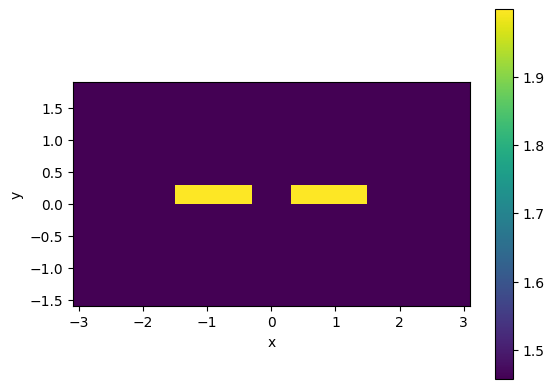

In [6]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [7]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)
#se popagan 4 modos porque los 4 numeros estan entre 1.4 y 3

2026-05-03 19:29:25.397 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [8]:
dcoupler_cs.fraction_te
#los dos primeros son modos te y los otros dos tm

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [9]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

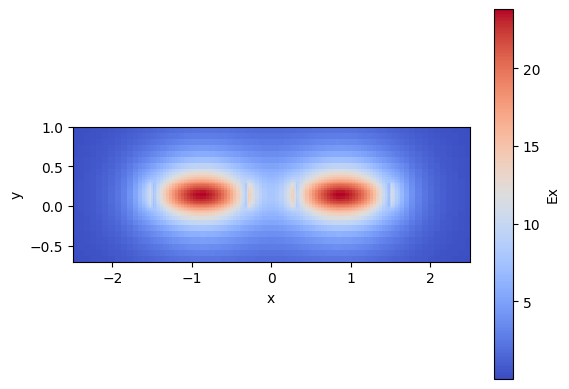

In [10]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
#modo TE0, dos lobulos positivos, simetrico

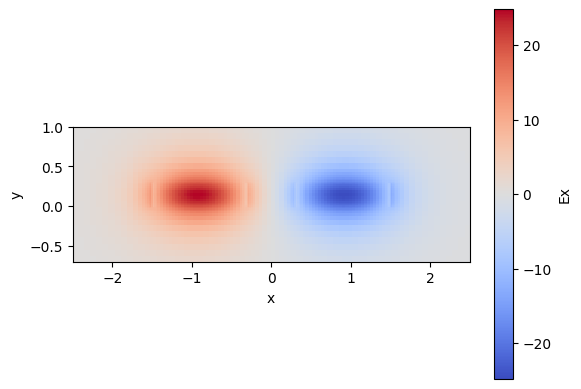

In [11]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
#modo TE1, simetria impar, antisimetrico, un lobulo positivo y otro negativo

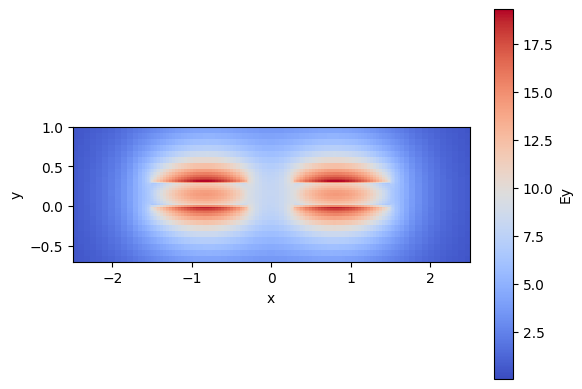

In [12]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

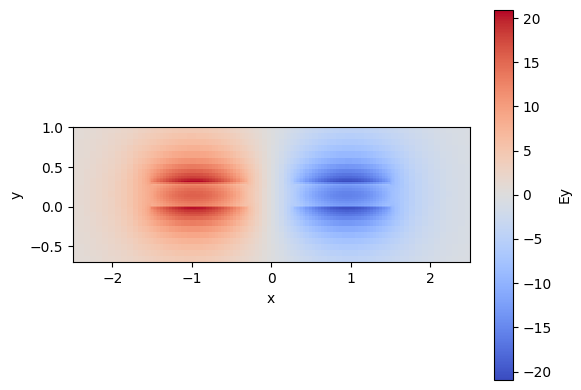

In [13]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [14]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)
#cada modo va a tener su propia Lpi, osea al ser dos longitudes de acoplamiento distintos, no se podra inyectar modo tm en la longitud del te y viceversa

93.83767536699492
52.26022367744298


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [15]:
dcoupler_cs.coupling_length() #no se recomienda usarla, no coincide a veces

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

93.83767536699492
[0.         0.00698893 0.02776035 0.06173358 0.10795887 0.16514395
 0.23169019 0.30573722 0.38521501 0.46790169 0.55148571 0.63363041
 0.71203937 0.78452062 0.84904788 0.90381726 0.94729762 0.97827345
 0.99587879 0.99962148 0.98939689 0.96549084 0.92857165 0.87967143
 0.82015721 0.75169277 0.67619207 0.59576578 0.5126623  0.42920483
 0.3477265  0.27050508 0.19969936 0.13728876 0.08501803 0.04434842
 0.01641688 0.00200427]


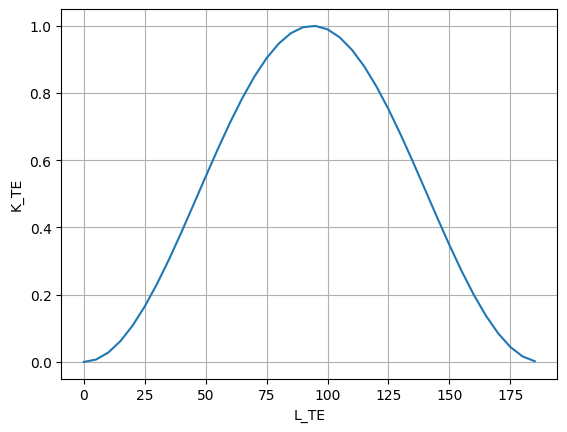

In [16]:
#para la constante de acoplo del modo TE
import math
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)
L=np.arange(0,(2*L_pi_TE),5)
#print(L)
x=L / L_pi_TE
K_TE=np.sin(0.5*np.pi*(x))**2
print(K_TE)

plt.plot(L, K_TE)
plt.xlabel('L_TE')
plt.ylabel('K_TE')
plt.grid()
plt.show()


52.26022367744298
[0.00000000e+00 2.24163617e-02 8.76554739e-02 1.89867642e-01
 3.19887967e-01 4.66058118e-01 6.15271683e-01 7.54149361e-01
 8.70238623e-01 9.53130273e-01 9.95391795e-01 9.93233790e-01
 9.46849757e-01 8.60398740e-01 7.41632410e-01 6.01200001e-01
 4.51693450e-01 3.06518326e-01 1.78691824e-01 7.96755622e-02
 1.83478794e-02 2.07749377e-04 2.68817149e-02 9.59780429e-02
 2.01301180e-01 3.33407281e-01 4.80450992e-01 6.29247574e-01
 7.66455114e-01 8.79770837e-01 9.59034239e-01 9.97138130e-01
 9.90665909e-01 9.40197909e-01 8.50259367e-01 7.28914663e-01
 5.87044223e-01 4.37368924e-01]


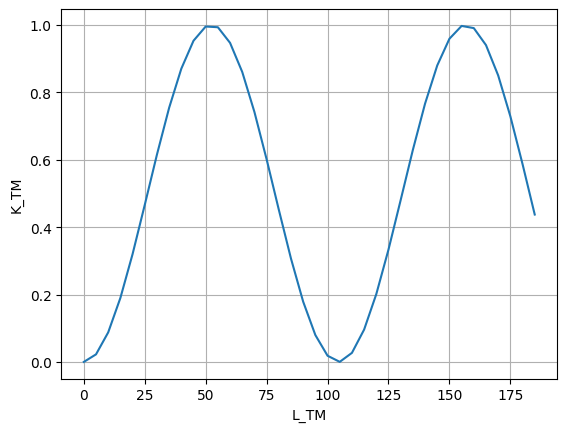

In [17]:
#para la constante de acoplo del modo TM
import math
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

L_pi_TM = 0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)
L=np.arange(0,(2*L_pi_TE),5)

#print(L)
x=L / L_pi_TM
K_TM=np.sin(0.5*np.pi*(x))**2
print(K_TM)

plt.plot(L, K_TM)
plt.xlabel('L_TM')
plt.ylabel('K_TM')
plt.grid()
plt.show()


## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [18]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
#cuantos mas modos, menos perdidas
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
#la lpi aqui da 94, no 93 como antes porque los modos se han calculado de forma distinta

/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605178396  µm


/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


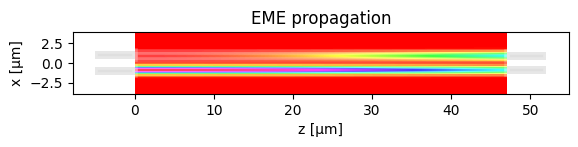

In [19]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()


/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Gap: 0.2 µm -> L_pi: 25.81 µm


/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/258 [00:00<?, ?it/s]

...

Gap: 1.2 µm -> L_pi: 580.43 µm


/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2147
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8916
Total OUT power: 0.8818
Excess loss [dB] =  0.5464
------------------------
Power over OUTs:  ['0.4407', '0.4410']
Ratio over OUTs ['0.4998', '0.5002']


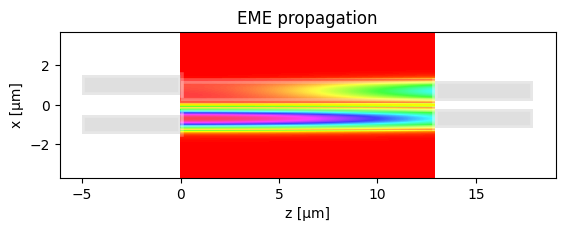

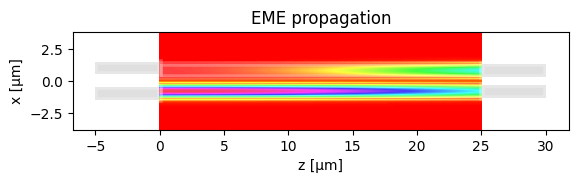

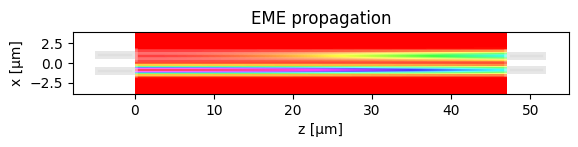

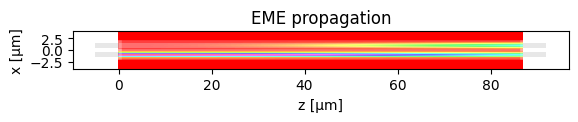

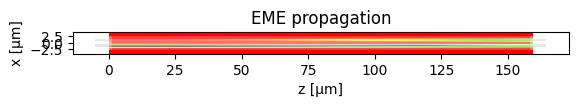

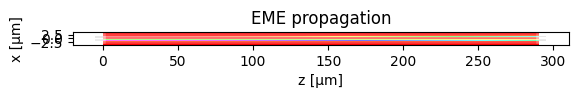

In [20]:
wg_width = 1.2
gaps = np.arange(0.2, 1.4, 0.2)  
resultados_L_pi = []
 
for wg_gap in gaps:
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = wg_gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2
 
    m.find_all_modes()
 
    # 3) Obtener L_pi y guardarlo
    L_pi = m.get_L_pi()
    resultados_L_pi.append(L_pi)
   
    print(f"Gap: {wg_gap:.1f} µm -> L_pi: {L_pi:.2f} µm")
 
 
    m.n_IN = 2
    m.n_OUT = 2
    m.L_MMI = 0.5 * L_pi
    m.propagation()
    #lpi SIEMPRE tiene que dar positivo
 

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



In [21]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 600 nm da 90 u de lpi
#lpi da 40 o 50 mm
#gaps pequeños dan lpis oequeños, gaps grandes dan lpis grandes. ver desde que distancia minima se da que lpi sea ese valor
#la deep da 3 mm y la shallow da 5 mm


L_pi teorica objetivo = 156817.08768975522 um
L_pi teorica objetivo = 156.81708768975523 mm
2026-05-03 19:45:38.557 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_2b1fc9cc2c72da25.npz.
gap = 0.5 um | L_pi_TE = 68.68020682854007 um
2026-05-03 19:45:38.562 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
gap = 0.6 um | L_pi_TE = 93.83767536699492 um
2026-05-03 19:45:38.572 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_5ef253f817e7933c.npz.
gap = 0.7 um | L_pi_TE = 127.78844134440102 um
2026-05-03 19:45:38.577 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_5676f4f02cc28a41.npz.
gap = 0.7999999999999999 um | L_pi_TE = 171.13967917538628 um
2026-05-03 19:45:38.580 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8e4e2d8628a2ba83.npz.
gap = 0.8999999999999999 um | L_pi_TE = 230.424

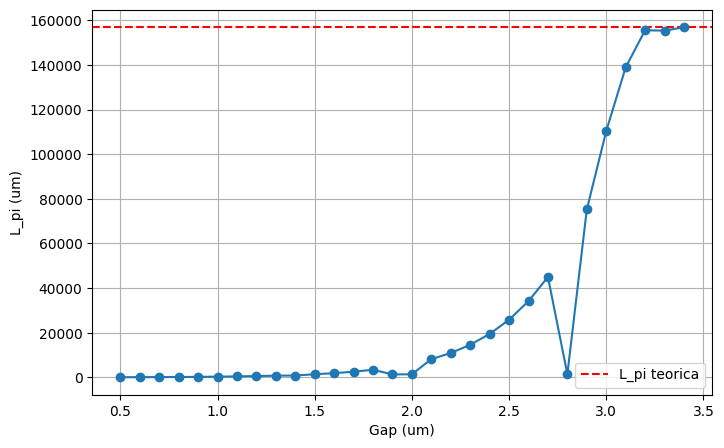

In [30]:
#guia deep
wavelength=1.55
L=10000
K_target=0.01
L_pi_target = (np.pi * L) / (2 * np.arcsin(np.sqrt(K_target)))

print("L_pi teorica objetivo =", L_pi_target, "um")
print("L_pi teorica objetivo =", L_pi_target/1000, "mm")


gap_values = np.arange(0.5, 4, 0.1)
Lpi_values = []

gap_min = None
Lpi_min = None

for gap_to_simulate in gap_values:

    dcoupler_cs = gt.modes.WaveguideCoupler(
        # Geometrical Parameters
        core_width=(1.2, 1.2),
        slab_thickness=0 * nm,      # deep
        core_thickness=300 * nm,
        gap=gap_to_simulate,

        # Materials
        core_material='sin',
        clad_material='sio2',

        # Modesolver Parameters
        wavelength=wavelength,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = dcoupler_cs.n_eff
    L_pi_TE = 0.5 * wavelength / (neff[0].real - neff[1].real)

    Lpi_values.append(L_pi_TE)

    print("gap =", gap_to_simulate, "um | L_pi_TE =", L_pi_TE, "um")

    if L_pi_TE >= L_pi_target:
        gap_min = gap_to_simulate
        Lpi_min = L_pi_TE
        break


print()
print("DEEP")
print("Gap minimo =", gap_min, "um")
print("L_pi en ese gap =", Lpi_min, "um =", Lpi_min/1000, "mm")


# 3) Grafica
plt.figure(figsize=(8,5))
plt.axhline(L_pi_target, color='r', linestyle='--', label='L_pi teorica')
plt.plot(gap_values[:len(Lpi_values)], Lpi_values, 'o-')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend()
plt.show()

L_pi teorica objetivo = 156817.08768975522 um
L_pi teorica objetivo = 156.81708768975523 mm
2026-05-03 19:54:25.624 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1f5f96d26cf71c4b.npz.
gap = 0.5 um | L_pi_TE = 43.89692478709102 um
2026-05-03 19:54:25.628 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0f20417fdb88e947.npz.
gap = 0.6 um | L_pi_TE = 54.21484230213076 um
2026-05-03 19:54:25.633 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_e7d6fb8511d93362.npz.
gap = 0.7 um | L_pi_TE = 66.91456646796485 um
2026-05-03 19:54:25.638 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b59556e260a84c92.npz.
gap = 0.7999999999999999 um | L_pi_TE = 82.32430630735294 um
2026-05-03 19:54:25.641 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fb2f459fb2c5c63c.npz.
gap = 0.8999999999999999 um | L_pi_TE = 101.31365

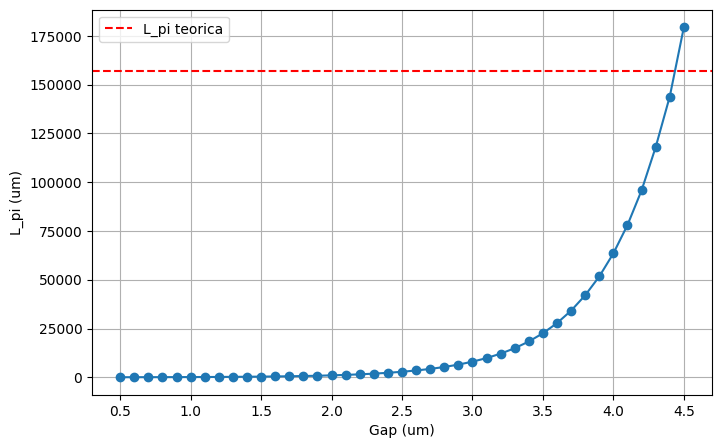

In [44]:
#guia shallow

# 1) L_pi teorica objetivo
L_pi_target = (np.pi * L) / (2 * np.arcsin(np.sqrt(K_target)))

print("L_pi teorica objetivo =", L_pi_target, "um")
print("L_pi teorica objetivo =", L_pi_target/1000, "mm")


# 2) Sweep de gap para deep
gap_values = np.arange(0.5, 5.6, 0.1)
Lpi_values = []

gap_min = None
Lpi_min = None

for gap_to_simulate in gap_values:

    dcoupler_cs = gt.modes.WaveguideCoupler(
        # Geometrical Parameters
        core_width=(1.2, 1.2),
        slab_thickness=150 * nm,      # shallow
        core_thickness=300 * nm,
        gap=gap_to_simulate,

        # Materials
        core_material='sin',
        clad_material='sio2',

        # Modesolver Parameters
        wavelength=wavelength,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = dcoupler_cs.n_eff
    L_pi_TE = 0.5 * wavelength / (neff[0].real - neff[1].real)

    Lpi_values.append(L_pi_TE)

    print("gap =", gap_to_simulate, "um | L_pi_TE =", L_pi_TE, "um")

    if L_pi_TE >= L_pi_target:
        gap_min = gap_to_simulate
        Lpi_min = L_pi_TE
        break


print()
print("SHALLOW")
print("Gap minimo =", gap_min, "um")
print("L_pi en ese gap =", Lpi_min, "um =", Lpi_min/1000, "mm")


# 3) Grafica
plt.figure(figsize=(8,5))
plt.axhline(L_pi_target, color='r', linestyle='--', label='L_pi teorica')
plt.plot(gap_values[:len(Lpi_values)], Lpi_values, 'o-')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend()
plt.show()

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [32]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-03 19:46:14.490 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [33]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

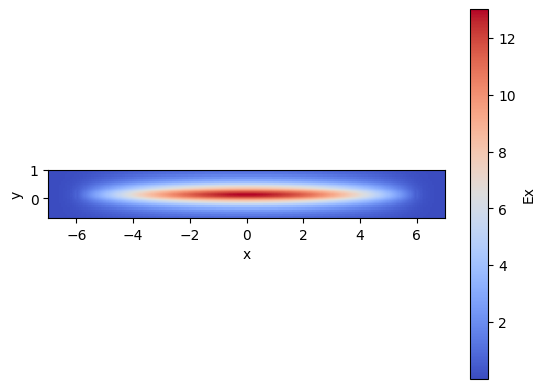

In [34]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

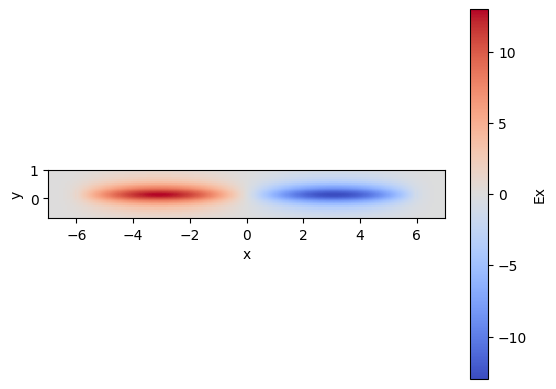

In [35]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

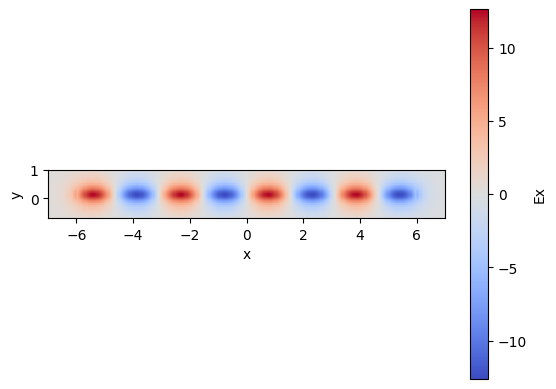

In [36]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #
                          #es un modo te con 7 cortes

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [37]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)
#la lpi 0se calcula con los dos primeros modos te 

219.41119794418495


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [38]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725423  µm


/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


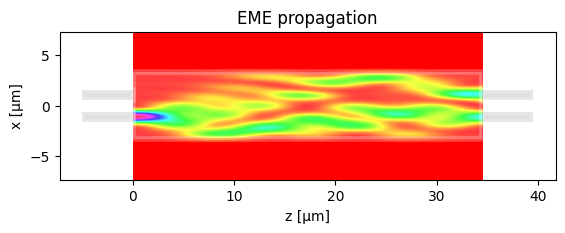

In [39]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/674 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.8000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9535
Total OUT power: 0.9020
Excess loss [dB] =  0.4480
------------------------
Power over OUTs:  ['0.4502', '0.4518']
Ratio over OUTs ['0.4991', '0.5009']


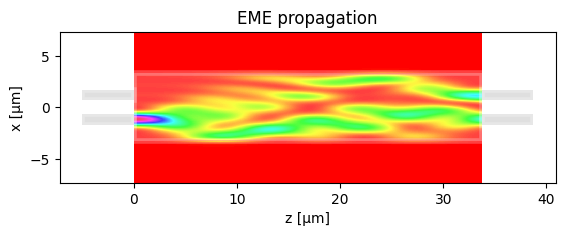

In [40]:
dy = 0.09
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.8  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [41]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 1.2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256414  µm


/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/692 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.1000
IO wg width 1.0000
IO wg width increment 1.2000
------------------------
Total power IN coupled 0.9992
Total OUT power: 0.9817
Excess loss [dB] =  0.0800
------------------------
Power over OUTs:  ['0.4908', '0.4910']
Ratio over OUTs ['0.4999', '0.5001']


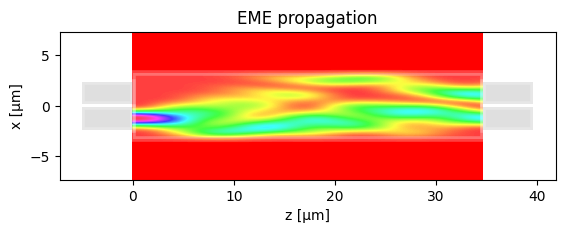

In [42]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.15
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = 0.1  # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [43]:
# Design flow for MMI
 
m = MMI_EME()
m.MMI_width = 6.2   # MMI width
m.wg_width_dw = 0.2 # STUDENT
 
# 1) Compute de MMI modes
m.find_all_modes()
 
# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  61.27610500996812  µm


/home/lidia/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/246 [00:00<?, ?it/s]

------- Pameters -------
MMI length 11.4893
MMI length increment 0.8000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9839
Total OUT power: 0.9838
Excess loss [dB] =  0.0711
------------------------
Power over OUTs:  ['0.2455', '0.2465', '0.2463', '0.2455']
Ratio over OUTs ['0.2495', '0.2506', '0.2504', '0.2495']


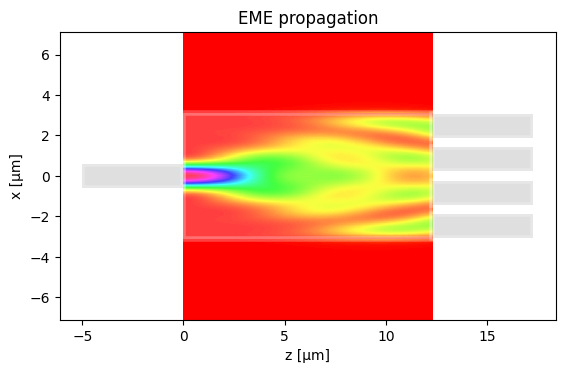

In [45]:
# IMPORTANT!!!
# # If you DON'T change neither the MMI width
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)
 
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  1# STUDENT
m.n_OUT = 4 # STUDENT
 
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
m.OUT_WVG_positions =mmi_Width*np.array([-3/8, -1/8, 1/8, 3/8]) # STUDENT
 
# MMI length (check class slides for type of MMI)
m.L_MMI = (3/16) * L_pi # STUDENT
m.dL_MMI = 0.8
# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

2026-05-03 19:54:52.482 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
gap = 0.2 um -> L_pi_TE = 17.69 um | L_pi_TM = 16.72 um
2026-05-03 19:54:52.488 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.
gap = 0.4 um -> L_pi_TE = 32.69 um | L_pi_TM = 25.45 um
2026-05-03 19:54:52.493 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fa4c4babd472f540.npz.
gap = 0.6 um -> L_pi_TE = 58.77 um | L_pi_TM = 38.43 um
2026-05-03 19:54:52.496 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.
gap = 0.8 um -> L_pi_TE = 103.11 um | L_pi_TM = 56.51 um
2026-05-03 19:54:52.501 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.
gap = 1.0 um -> L_pi_TE = 183.51 um | L_pi_TM = 85.35 um
2026-05-03 19:54:52.505 | INFO     | gplugins.tidy3d.modes

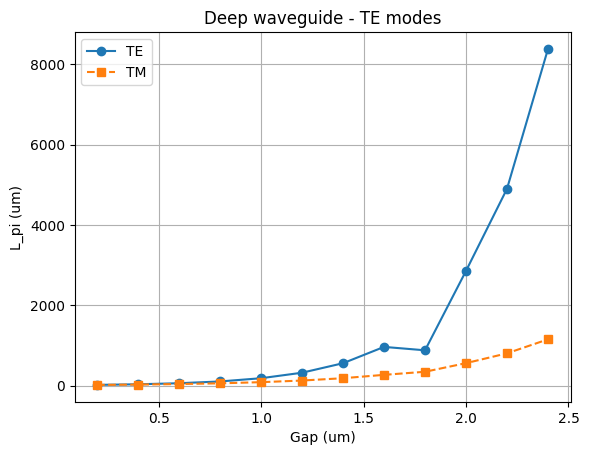

In [46]:
#GUIA DEEP
#ap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
lambda_c = 1.55

# --- E1: Directional coupler gap dependence (DEEP) ---

gap_values = np.arange(0.2, 2.6, 0.2)
Lpi_TE = []
Lpi_TM = []

for gap_to_simulate in gap_values:

    dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=lambda_c,
        core_width=(1.0, 1.0),
        gap=gap_to_simulate,
        slab_thickness=0 * nm,  # DEEP
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )
    
    neff = dcoupler_cs.n_eff

     # TE
    L_pi_TE = 0.5 * lambda_c / (neff[0].real - neff[1].real)
    Lpi_TE.append(L_pi_TE)

    # TM
    L_pi_TM = 0.5 * lambda_c / (neff[2].real - neff[3].real)
    Lpi_TM.append(L_pi_TM)

    print(f"gap = {gap_to_simulate:.1f} um -> L_pi_TE = {L_pi_TE:.2f} um | L_pi_TM = {L_pi_TM:.2f} um")


# --- Plot ---
plt.figure()
plt.plot(gap_values, Lpi_TE, 'o-', label='TE')
plt.plot(gap_values, Lpi_TM, 's--', label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.title("Deep waveguide - TE modes")
plt.grid(True)
plt.legend()
plt.show()


2026-05-03 19:55:00.546 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8c8eb63846dcafc2.npz.
gap = 0.2 um -> L_pi_TE = 17.71 um | L_pi_TM = 38.52 um
2026-05-03 19:55:00.557 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9f55a49562c957ac.npz.
gap = 0.4 um -> L_pi_TE = 26.45 um | L_pi_TM = 51.07 um
2026-05-03 19:55:00.561 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0aace39711989615.npz.
gap = 0.6 um -> L_pi_TE = 39.25 um | L_pi_TM = 66.68 um
2026-05-03 19:55:00.566 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_469dd463acb1cce2.npz.
gap = 0.8 um -> L_pi_TE = 57.95 um | L_pi_TM = 88.93 um
2026-05-03 19:55:00.570 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_12053cc304837a1c.npz.
gap = 1.0 um -> L_pi_TE = 85.76 um | L_pi_TM = 113.95 um
2026-05-03 19:55:00.574 | INFO     | gplugins.tidy3d.modes:

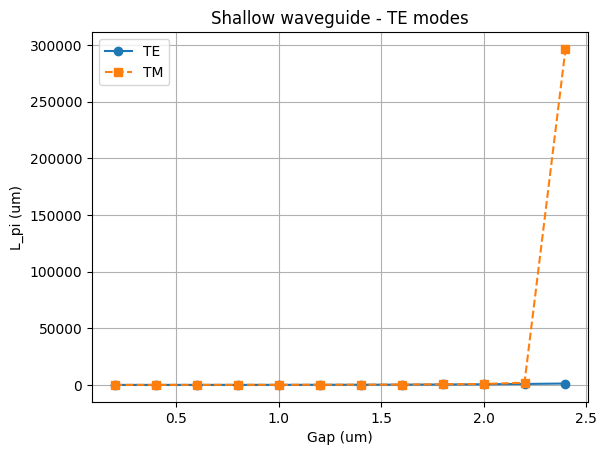

In [47]:
#GUIA SHALLOW

lambda_c = 1.55

# --- E1: Directional coupler gap dependence (SHALLOW) ---

gap_values = np.arange(0.2, 2.6, 0.2)
Lpi_TE = []
Lpi_TM = []

for gap_to_simulate in gap_values:

    dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=lambda_c,
        core_width=(1.0, 1.0),
        gap=gap_to_simulate,
        slab_thickness=150 * nm,  # SHALLOW
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = dcoupler_cs.n_eff

    # TE
    L_pi_TE = 0.5 * lambda_c / (neff[0].real - neff[1].real)
    Lpi_TE.append(L_pi_TE)

    # TM
    L_pi_TM = 0.5 * lambda_c / (neff[2].real - neff[3].real)
    Lpi_TM.append(L_pi_TM)

    print(f"gap = {gap_to_simulate:.1f} um -> L_pi_TE = {L_pi_TE:.2f} um | L_pi_TM = {L_pi_TM:.2f} um")

# --- Plot ---
plt.figure()
plt.plot(gap_values, Lpi_TE, 'o-', label='TE')
plt.plot(gap_values, Lpi_TM, 's--', label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.title("Shallow waveguide - TE modes")
plt.grid(True)
plt.legend()
plt.show()

### E2. Directional coupler wavelength dependence

2026-05-03 19:55:04.725 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fc2c62c75e0d5f6e.npz.
2026-05-03 19:55:04.738 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_6eef774a0d3d05cd.npz.
2026-05-03 19:55:04.742 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7204f407c71c1ae9.npz.
2026-05-03 19:55:04.747 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_a0ce23b6137b45c7.npz.
2026-05-03 19:55:04.751 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_28b1e0ce04fc49df.npz.
2026-05-03 19:55:04.755 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b966fe1ac7f3af0a.npz.
2026-05-03 19:55:04.760 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_6a889f60cad0254f.npz.
2026-05-03 19:55:04.763 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

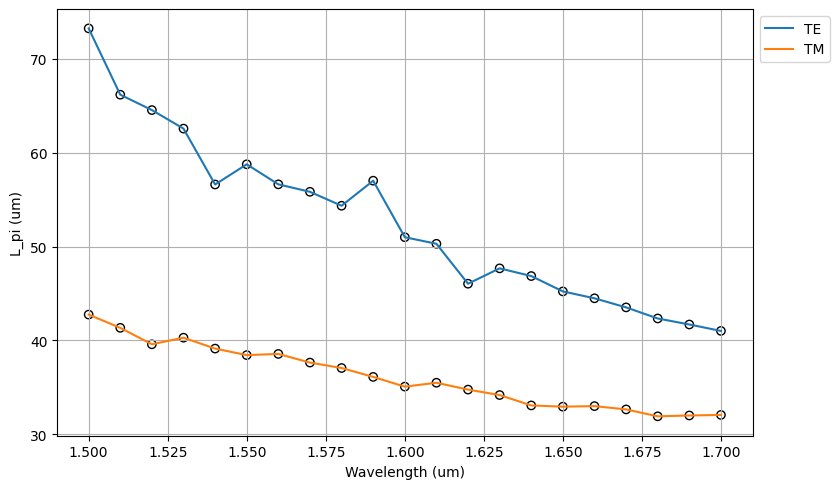

In [48]:
#GUIA DEEP

# --- E2: Directional coupler wavelength dependence (DEEP) ---

wavelength = np.arange(1.5, 1.7 + 0.01, 0.01)
L_pi_TE = []
L_pi_TM = []

for wl in wavelength:

    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wl,
        core_width=(1.0, 1.0),
        gap=600 * nm,
        slab_thickness=0 * nm,  # DEEP
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    deep_neff = deep_dcoupler_cs.n_eff

    # TE
    L_pi_TE_val = 0.5 * wl / (deep_neff[0].real - deep_neff[1].real)
    L_pi_TE.append(L_pi_TE_val)

    # TM
    L_pi_TM_val = 0.5 * wl / (deep_neff[2].real - deep_neff[3].real)
    L_pi_TM.append(L_pi_TM_val)


# --- Plot ---
plt.figure(figsize=(10, 5))
# TE
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(wavelength, L_pi_TE, label='TE')

# TM
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(wavelength, L_pi_TM, label='TM')

plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

2026-05-03 19:56:05.585 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_96366e64f2261531.npz.
2026-05-03 19:56:05.591 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_82dae10517347759.npz.
2026-05-03 19:56:05.595 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_825d0a38cb57f00d.npz.
2026-05-03 19:56:05.598 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_21db26ab7959afe7.npz.
2026-05-03 19:56:05.603 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8d2597f571f62117.npz.
2026-05-03 19:56:05.608 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_35db2e2c835b791a.npz.
2026-05-03 19:56:05.612 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_c7c71ebc194077d8.npz.
2026-05-03 19:56:05.616 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

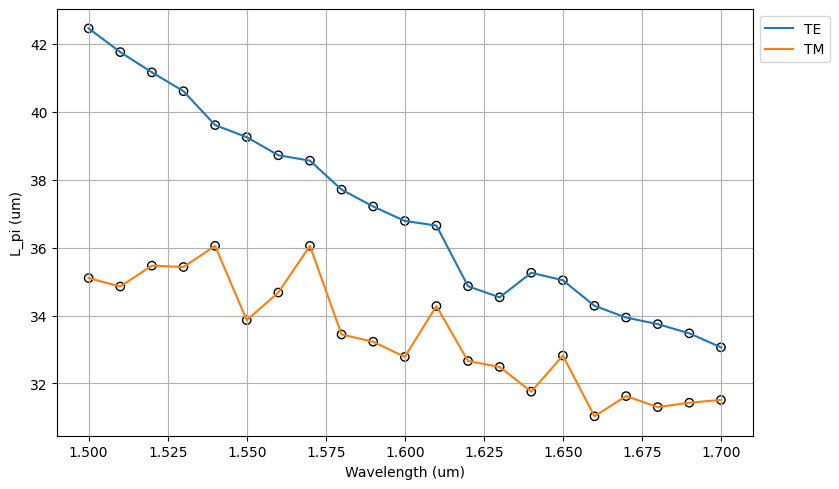

In [52]:
#GUIA SHALLOW

# --- E2: Directional coupler wavelength dependence (SHALLOW) ---

wavelength = np.arange(1.5, 1.7 + 0.01, 0.01)
L_pi_TE = []
L_pi_TM = []

for wl in wavelength:

    shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wl,
        core_width=(1.0, 1.0),
        gap=600 * nm,
        slab_thickness=150 * nm,  # SHALLOW
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=8,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    shallow_neff = shallow_dcoupler_cs.n_eff
    te_fraction = shallow_dcoupler_cs.fraction_te

    # TE
    te_indices = np.where(te_fraction > 0.5)[0]
    if len(te_indices) >= 2:
        n_even = shallow_neff[te_indices[0]].real
        n_odd = shallow_neff[te_indices[1]].real
        L_pi_TE_val = 0.5 * wl / (n_even - n_odd)
        L_pi_TE.append(L_pi_TE_val)
    else:
        L_pi_TE.append(np.nan)

    # TM
    tm_indices = np.where(te_fraction < 0.5)[0]
    if len(tm_indices) >= 2:
        n_even_tm = shallow_neff[tm_indices[0]].real
        n_odd_tm = shallow_neff[tm_indices[1]].real
        L_pi_TM_val = 0.5 * wl / (n_even_tm - n_odd_tm)
        L_pi_TM.append(L_pi_TM_val)
    else:
        L_pi_TM.append(np.nan)


# --- Plot ---
plt.figure(figsize=(10, 5))

# TE
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(wavelength, L_pi_TE, label='TE')

# TM
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(wavelength, L_pi_TM, label='TM')

plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E3. MMI coupler wavelength dependence

2026-05-03 19:56:11.670 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9a2f1ddbafc80a93.npz.
2026-05-03 19:56:11.676 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4f9138f5bec1fca2.npz.
2026-05-03 19:56:11.680 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_eca50a73c8b35e9b.npz.
2026-05-03 19:56:11.685 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7a8d398b6f033eff.npz.
2026-05-03 19:56:11.689 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_55339f95de89c4be.npz.
2026-05-03 19:56:11.692 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cc174b674ffff0ec.npz.
2026-05-03 19:56:11.697 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4060347800ce3e94.npz.
2026-05-03 19:56:11.700 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_42873e3c62be4063.npz.


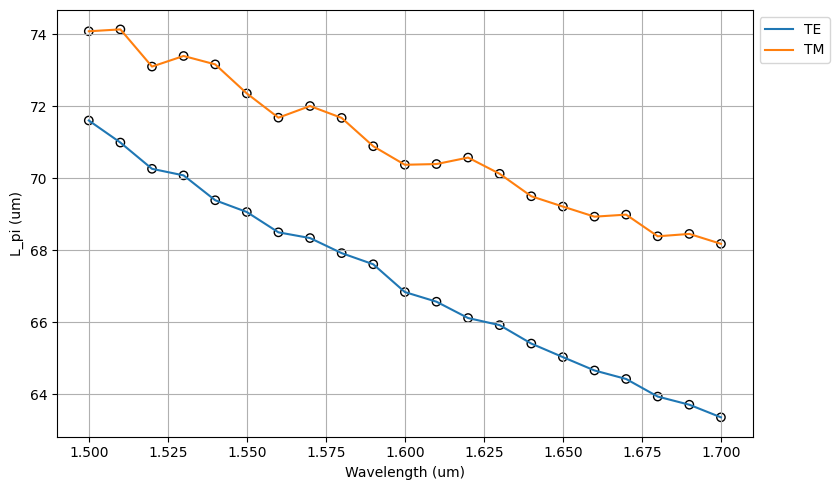

In [53]:
#GUIA DEEP

# --- E3: MMI coupler wavelength dependence (DEEP) ---

mmi_body_w = 6.6

lambda_c = np.arange(1.5, 1.7 + 0.01, 0.01)
L_pi_TE = []
L_pi_TM = []

for wl in lambda_c:

    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=300 * nm,
        slab_thickness=0 * nm,  # DEEP
        core_material='sin',
        clad_material='sio2',
        wavelength=wl,
        num_modes=15,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )

    neff = mmi_body_waveguide.n_eff

    te_fraction = mmi_body_waveguide.fraction_te

    # TE
    te_indices = np.where(te_fraction > 0.5)[0]
    if len(te_indices) >= 2:
        n_even = neff[te_indices[0]].real
        n_odd = neff[te_indices[1]].real
        L_pi_TE.append(0.5 * wl / (n_even - n_odd))
    else:
        L_pi_TE.append(np.nan)

    # TM
    tm_indices = np.where(te_fraction < 0.5)[0]
    if len(tm_indices) >= 2:
        n_even_tm = neff[tm_indices[0]].real
        n_odd_tm = neff[tm_indices[1]].real
        L_pi_TM.append(0.5 * wl / (n_even_tm - n_odd_tm))
    else:
        L_pi_TM.append(np.nan)


# --- Plot ---
plt.figure(figsize=(10, 5))
# TE
plt.scatter(lambda_c, L_pi_TE, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(lambda_c, L_pi_TE, label='TE')

# TM
plt.scatter(lambda_c, L_pi_TM, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(lambda_c, L_pi_TM, label='TM')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

2026-05-03 20:07:01.506 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c26c25376372bde5.npz.
2026-05-03 20:07:01.510 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c051a2f7db917722.npz.
2026-05-03 20:07:01.514 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fc4096826c51432d.npz.
2026-05-03 20:07:01.516 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ee8712a0bc064dcf.npz.
2026-05-03 20:07:01.523 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a0df88c3277ba061.npz.
2026-05-03 20:07:01.527 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_869eaa6141b95414.npz.
2026-05-03 20:07:01.531 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cdc4c4c6cae6ff97.npz.
2026-05-03 20:07:01.540 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_774fe4b377f9f63a.npz.


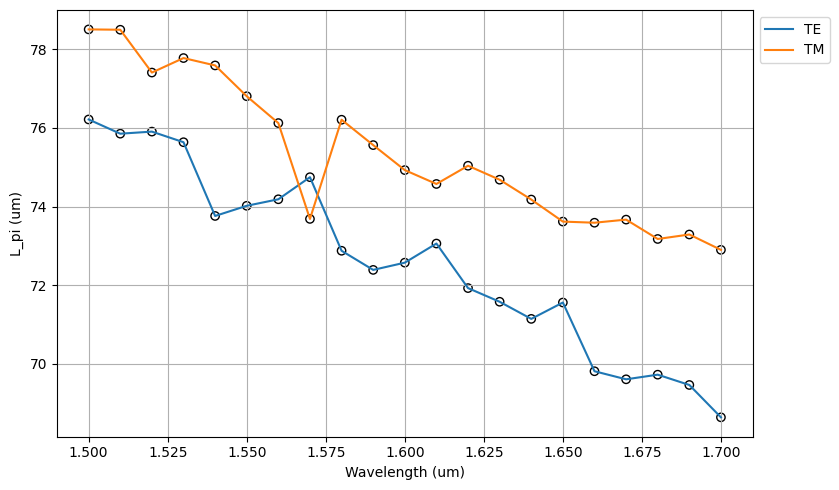

In [63]:
#GUIA SHALLOW

# --- E3: MMI coupler wavelength dependence (SHALLOW) ---

mmi_body_w = 6.6

lambda_c = np.arange(1.5, 1.7 + 0.01, 0.01)
L_pi_TE = []
L_pi_TM = []

for wl in lambda_c:

    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=300 * nm,
        slab_thickness=150 * nm,  # SHALLOW
        core_material='sin',
        clad_material='sio2',
        wavelength=wl,
        num_modes=15,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )

    neff = mmi_body_waveguide.n_eff
    te_frac = mmi_body_waveguide.fraction_te

    # TE
    te_idx = np.where(te_frac > 0.5)[0]
    d_n_eff_TE = neff[te_idx[0]].real - neff[te_idx[1]].real
    Lpi_val_TE = 0.5 * wl / d_n_eff_TE
    L_pi_TE.append(Lpi_val_TE)

    # TM
    tm_idx = np.where(te_frac < 0.5)[0]
    d_n_eff_TM = neff[tm_idx[0]].real - neff[tm_idx[1]].real
    Lpi_val_TM = 0.5 * wl / d_n_eff_TM
    L_pi_TM.append(Lpi_val_TM)


# --- Plot ---
plt.figure(figsize=(10, 5))

# TE
plt.scatter(lambda_c, L_pi_TE, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(lambda_c, L_pi_TE, label='TE')

# TM
plt.scatter(lambda_c, L_pi_TM, edgecolors='k', facecolors='none', label='_nolegend_')
plt.plot(lambda_c, L_pi_TM, label='TM')

plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E4. MMI coupler body width dependence

2026-05-03 20:07:10.411 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_47f426520d618363.npz.
2026-05-03 20:07:10.427 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0c9dd7989eb63169.npz.
2026-05-03 20:07:10.431 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1736e1c1aaf31dc6.npz.
2026-05-03 20:07:10.438 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f78fcc329c364ed8.npz.
2026-05-03 20:07:10.441 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a1de79a988dd243a.npz.
2026-05-03 20:07:10.444 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d77c5c70cde8e35f.npz.
2026-05-03 20:07:10.447 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_88a1ff09686df0a6.npz.
2026-05-03 20:07:10.453 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a540ae376bff1262.npz.


<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2855/1332329102.py:54: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(valid_widths_te, L_pi_TE, 'o-', label='$L_\pi$ TE')
/tmp/ipykernel_2855/1332329102.py:57: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(valid_widths_tm, L_pi_TM, 'o--', label='$L_\pi$ TM')
/tmp/ipykernel_2855/1332329102.py:63: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$L_\pi$ (μm)")
/tmp/ipykernel_2855/1332329102.py:64: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Longitud de batido $L_\pi$ vs Ancho del MMI (TE vs TM)")


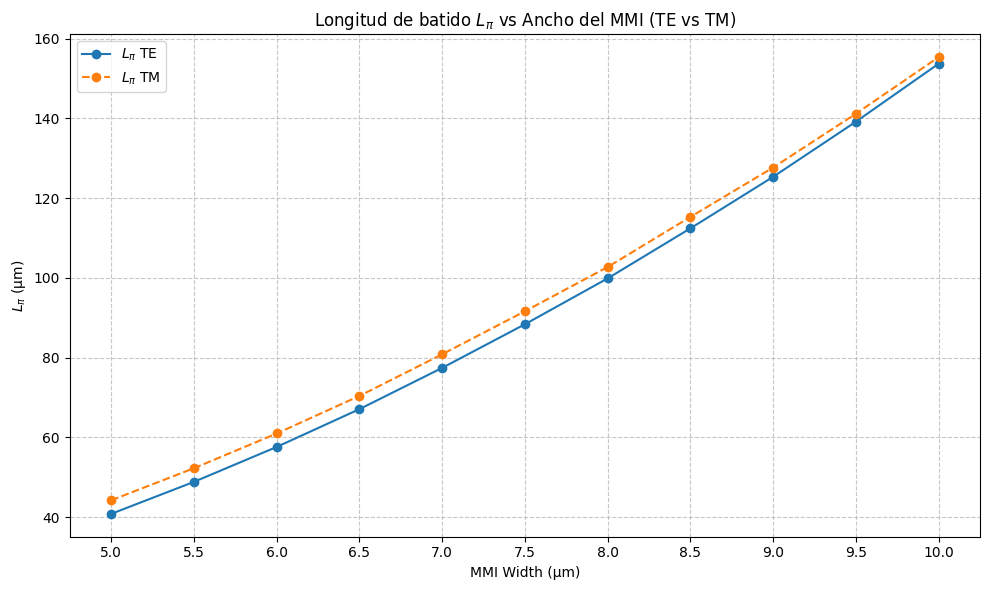

In [64]:
# Definición del rango de anchos de 5 a 10 con saltos de 0.5
width_sweep = np.arange(5, 10.1, 0.5)
lambda_c=1.55
L_pi_TE = []
L_pi_TM = []
valid_widths_te = []
valid_widths_tm = []
 
for w in width_sweep:
    # Ejecutamos el solver para cada ancho específico
    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=w,
        core_thickness=300 * nm,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=20, # Aumentamos ligeramente el número de modos para asegurar encontrar TM
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
   
    # Extraemos índices efectivos y fracciones TE
    neffs = mmi_body_waveguide.n_eff
    te_fracs = mmi_body_waveguide.fraction_te
   
    # --- PROCESAMIENTO MODOS TE ---
    te_indices = np.where(te_fracs > 0.5)[0]
    if len(te_indices) >= 2:
        n0_te = neffs[te_indices[0]].real
        n1_te = neffs[te_indices[1]].real
       
        l_pi_te_val = abs(0.5 * lambda_c / (n0_te - n1_te))
        L_pi_TE.append(l_pi_te_val)
        valid_widths_te.append(w)
 
    # --- PROCESAMIENTO MODOS TM ---
    # Los modos TM tienen una fracción TE baja (te_fracs < 0.5)
    tm_indices = np.where(te_fracs < 0.5)[0]
    if len(tm_indices) >= 2:
        n0_tm = neffs[tm_indices[0]].real
        n1_tm = neffs[tm_indices[1]].real
       
        l_pi_tm_val = abs(0.5 * lambda_c / (n0_tm - n1_tm))
        L_pi_TM.append(l_pi_tm_val)
        valid_widths_tm.append(w)
 
# --- GENERACIÓN DE LA GRÁFICA ---
plt.figure(figsize=(10, 6))
 
# Plot TE
plt.plot(valid_widths_te, L_pi_TE, 'o-', label='$L_\pi$ TE')
 
# Plot TM
plt.plot(valid_widths_tm, L_pi_TM, 'o--', label='$L_\pi$ TM')
 
# Ajuste del eje X
plt.xticks(np.arange(5, 10.1, 0.5))
 
plt.xlabel("MMI Width (μm)")
plt.ylabel("$L_\pi$ (μm)")
plt.title("Longitud de batido $L_\pi$ vs Ancho del MMI (TE vs TM)")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

2026-05-03 20:07:20.683 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2cc16b7ca9ffdda3.npz.
2026-05-03 20:07:20.693 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5266d83ee722b523.npz.
2026-05-03 20:07:20.697 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_76f00aa2d341ea16.npz.
2026-05-03 20:07:20.701 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dc7f594730171bb6.npz.
2026-05-03 20:07:20.705 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_51bee8c9c6f3cb01.npz.
2026-05-03 20:07:20.708 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0e6424754e8c3042.npz.
2026-05-03 20:07:20.711 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_384b888d7ec6b927.npz.
2026-05-03 20:07:20.714 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_96739692158d550a.npz.


<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2855/1236816703.py:54: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(valid_widths_te, L_pi_TE, 'o-', label='$L_\pi$ TE')
/tmp/ipykernel_2855/1236816703.py:57: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(valid_widths_tm, L_pi_TM, 'o-', label='$L_\pi$ TM')
/tmp/ipykernel_2855/1236816703.py:63: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$L_\pi$ (μm)")
/tmp/ipykernel_2855/1236816703.py:64: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Longitud de batido $L_\pi$ vs Ancho del MMI (TE vs TM)")


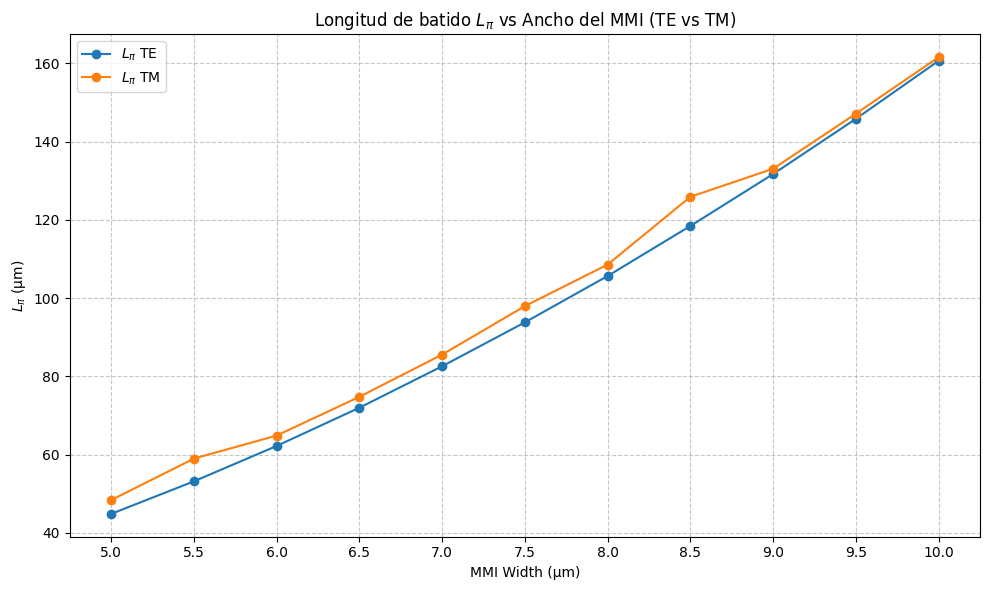

In [65]:
# Definición del rango de anchos de 5 a 10 con saltos de 0.5
width_sweep = np.arange(5, 10.1, 0.5)
 
L_pi_TE = []
L_pi_TM = []
valid_widths_te = []
valid_widths_tm = []
 
for w in width_sweep:
    # Ejecutamos el solver para cada ancho específico
    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=w,
        core_thickness=300 * nm,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=20, # Aumentamos ligeramente el número de modos para asegurar encontrar TM
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
   
    # Extraemos índices efectivos y fracciones TE
    neffs = mmi_body_waveguide.n_eff
    te_fracs = mmi_body_waveguide.fraction_te
   
    # --- PROCESAMIENTO MODOS TE ---
    te_indices = np.where(te_fracs > 0.5)[0]
    if len(te_indices) >= 2:
        n0_te = neffs[te_indices[0]].real
        n1_te = neffs[te_indices[1]].real
       
        l_pi_te_val = abs(0.5 * lambda_c / (n0_te - n1_te))
        L_pi_TE.append(l_pi_te_val)
        valid_widths_te.append(w)
 
    # --- PROCESAMIENTO MODOS TM ---
    # Los modos TM tienen una fracción TE baja (te_fracs < 0.5)
    tm_indices = np.where(te_fracs < 0.5)[0]
    if len(tm_indices) >= 2:
        n0_tm = neffs[tm_indices[0]].real
        n1_tm = neffs[tm_indices[1]].real
       
        l_pi_tm_val = abs(0.5 * lambda_c / (n0_tm - n1_tm))
        L_pi_TM.append(l_pi_tm_val)
        valid_widths_tm.append(w)
 
# --- GENERACIÓN DE LA GRÁFICA ---
plt.figure(figsize=(10, 6))
 
# Plot TE
plt.plot(valid_widths_te, L_pi_TE, 'o-', label='$L_\pi$ TE')
 
# Plot TM
plt.plot(valid_widths_tm, L_pi_TM, 'o-', label='$L_\pi$ TM')
 
# Ajuste del eje X
plt.xticks(np.arange(5, 10.1, 0.5))
 
plt.xlabel("MMI Width (μm)")
plt.ylabel("$L_\pi$ (μm)")
plt.title("Longitud de batido $L_\pi$ vs Ancho del MMI (TE vs TM)")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points